# Getting Query Tensor
---

This notebook demonstrates an unrefined user-facing API to get Query tensor for
testing store Q implementations. This notebook and example, overall, will be
refined in future PR. Particularly, this notebook still uses a separate context
for QCache, which is a thin wrapper over LMCacheKVCacheContext.

Requirements:
* This experiment requires a GPU. To demonstrate how token dropping increases 
  the decoding batch size, adjust the GPU memory utilization together with the 
  number of requests. This example uses one RTX 6000 PRO.
* This example uses shared memory for data transfer between LMCache server and
  the SDK. If shared memory is unavailable, the SDK automatically falls back to pickle.

## Setup vLLM and LMCache server
Follow below instructions (1-4), then proceed to below Python cell.

**1. Start LMCache server first**

To use shared memory, specify the `--shm-name` and `--no-l1-use-lazy`

```sh
lmcache server \
    --l1-size-gb 150 \
    --eviction-policy LRU \
    --chunk-size 256 \
    --port 6555 \
    --http-port 8080 \
    --shm-name lmcache_kvcache_sdk_e2e \
    --no-l1-use-lazy
```

**2. Wait until LMCache server is ready**

```sh
curl -sf http://localhost:8080/healthcheck && echo " LMCache ready"
```

**3. Start vLLM once LMCache server is ready**

We pass --no-enable-prefix-caching to disable vLLM's built-in prefix caching. 
This ensures the prefilled KV cache is always served from LMCache rather than 
vLLM, so the decoding throughput improvement can be attributed entirely to the 
tokens dropped through LMCache.

```sh
vllm serve Qwen/Qwen3-8B \
    --port 8000 \
    --served-model-name Qwen/Qwen3-8B \
    --no-enable-prefix-caching \
    --enforce-eager \
    --gpu-memory-utilization 0.65 \
    --kv-transfer-config '{"kv_connector":"LMCacheMPConnector","kv_role":"kv_both","kv_connector_extra_config":{"lmcache.mp.port":6555}}' \
    --trust-remote-code \
    --return-tokens-as-token-ids
```

**4. Wait until vLLM is ready**

```sh
curl -sf http://localhost:8000/v1/models && echo " vLLM ready"
```

## Run E2E KV Edit Example

In [1]:
# SPDX-License-Identifier: Apache-2.0
"""End-to-end KV cache remapping driver for the SDK example."""

# Standard
from datasets import load_dataset
import math
import matplotlib.pyplot as plt
import sys
from transformers import AutoTokenizer, AutoConfig

# Third Party
import torch
import torch.nn.functional as F

# First Party
from lmcache.logging import init_logger
import lmcache.sdk as lmc_sdk
from lmcache.banner import print_banner_once
from utils import rerotate_k_cache, make_post_completion

print_banner_once(sys.stdout)
logger = init_logger(__name__)

/home/rani/LMCache/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[2026-07-09 19:43:26,418] LMCache INFO: torch_dev=<module 'torch.cuda' from '/home/rani/LMCache/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py'>, torch_device_type=cuda (__init__.py:208:lmcache.v1.platform)
[2026-07-09 19:43:26,756] LMCache INFO: Using backend: lmcache.c_ops (__init__.py:198:lmcache.v1.platform)
[2026-07-09 19:43:26,811] LMCache INFO: multi_layer_block_kv_transfer mode: ptr (base.py:94:lmcache.v1.multiprocess.transfer_context.base)



 _     __  __    ____           _          
| |   |  \/  |  / ___|__ _  ___| |__   ___      LMCache v0.5.1rc3.dev6 (g30352f22)
| |   | |\/| | | |   / _` |/ __| '_ \ / _ \     Website:  https://lmcache.ai/
| |___| |  | | | |__| (_| | (__| | | |  __/     Recipes:  https://docs.lmcache.ai/recipes
|_____|_|  |_|  \____\__,_|\___|_| |_|\___|     LinkedIn: https://www.linkedin.com/company/lmcache-lab
Set LMCACHE_DISABLE_BANNER=1 to hide this banner.



## Setting up hyperparameters

In [ ]:
model_name = "Qwen/Qwen3-8B"
vllm_url = "http://localhost:8000"
lmcache_url = "http://localhost:8080"
lmcache_mq_url = "tcp://localhost:6555"
chunk_size = 256
max_tokens = 5120
timeout = 60  # timeout for context retrieval (seconds)
trust_remote_code = True

## Configuring the model and LMCache endpoint

In [3]:
tokenizer = AutoTokenizer.from_pretrained(
    model_name, trust_remote_code=trust_remote_code
)
config = AutoConfig.from_pretrained(model_name, trust_remote_code=trust_remote_code)
head_size = getattr(
    config, "head_dim", config.hidden_size // config.num_attention_heads
)
work_device = torch.device("cpu")
post_completion = make_post_completion(vllm_url, model_name, timeout)
ctx = lmc_sdk.kvcache.connect(
    url=lmcache_mq_url,
    http_url=lmcache_url,
    model_name=model_name,
    timeout=timeout,
)
qctx = lmc_sdk.qcache.connect(
    url=lmcache_mq_url,
    http_url=lmcache_url,
    model_name=model_name,
    timeout=timeout,
)

[2026-07-09 19:43:28,171] LMCache INFO: Initialized LMCacheSDKContext with instance_id=2775430930211746031, model_name=Qwen/Qwen3-8B, chunk_size=256, shm_name=lmcache_l1_pool_lmcache_kvcache_sdk_e2e, kind=LMCacheSDKCacheKind.KV (context.py:150:lmcache.sdk.context)
[2026-07-09 19:43:28,174] LMCache INFO: Creating transfer context (device_type=cpu, mode=auto) (worker_transfer.py:641:lmcache.v1.multiprocess.transfer_context.worker_transfer)
[2026-07-09 19:43:28,403] LMCache INFO: Using AsyncEngineDrivenTransferContext for store path (worker_transfer.py:101:lmcache.v1.multiprocess.transfer_context.worker_transfer)
[2026-07-09 19:43:28,404] LMCache INFO: Engine KV Format: EngineKVFormat.NL_X_NB_TWO_NH_BS_HS NL x [NB, 2, NH, BS, HS] (detection.py:44:lmcache.v1.gpu_connector.kv_format.detection)
[2026-07-09 19:43:28,405] LMCache INFO: Creating EngineDrivenContextShm (shm_name=lmcache_l1_pool_lmcache_kvcache_sdk_e2e, pool_size=214748364800) (base.py:235:lmcache.v1.multiprocess.transfer_context

## Constructing Prompt

In [4]:
prompts = []
ds = load_dataset("raniayu/token-dropping-demo", split="train")
for i, example in enumerate(ds):
    prompt = tokenizer.encode(ds[i]["prompt"], return_tensors="pt").squeeze(0).tolist()
    prompts.append(prompt)

print(f"Loaded {len(prompts)} prompts from the dataset.")
print(f"Total prompts length: {sum(len(p) for p in prompts)} tokens.")
print(f"Mean prompt length: {sum(len(p) for p in prompts) / len(prompts):.2f} tokens.")
print(f"Max prompt length: {max(len(p) for p in prompts)} tokens.")
print(f"Min prompt length: {min(len(p) for p in prompts)} tokens.")

Loaded 30 prompts from the dataset.
Total prompts length: 418566 tokens.
Mean prompt length: 13952.20 tokens.
Max prompt length: 16630 tokens.
Min prompt length: 10007 tokens.


## Baseline (without token dropping)

In [5]:
batch = lmc_sdk.batch.LMCacheBatchedStream()
for i, prompt in enumerate(prompts):
    stream = lmc_sdk.stream.create_request(
        contexts=[ctx, qctx],
        post_completion=post_completion,
        prompt_token_ids=prompt,
    )
    batch.add(stream)
results = batch.prefill(
    sampling_params={"max_tokens": 1, "temperature": 1.0, "ignore_eos": True}
)
results.emit()

logger.info("\n\n")

results = batch.decode(
    sampling_params={"max_tokens": max_tokens, "temperature": 1.0, "ignore_eos": True}
)
results.emit()
before_drop_data = results.to_dict()

[2026-07-09 19:44:55,106] LMCache INFO: 

 (3040349831.py:14:__main__)


======================= Batched Stream Metrics (prefill) =======================
-------------------------------- Configuration ---------------------------------
Number of Streams:                                                            30
----------------------------------- Results ------------------------------------
Total Duration (s):                                                        27.65
Total Input Tokens:                                                       418566
Input Throughput (tokens/s):                                            15140.24
======================= Batched Stream Metrics (decode) ========================
-------------------------------- Configuration ---------------------------------
Number of Streams:                                                            30
----------------------------------- Results ------------------------------------
Total Duration (s):                                                       671.83
Total Output Tokens:        

## Clear LMCache

In [6]:
!curl -X POST {lmcache_url}/cache/clear

{"status":"ok","cleared":{"tier":"l1"}}

## With Token Dropping

In [7]:
CUDA_VISIBLE_DEVICES = "0"

snapkv_window_size = 64
snapkv_drop_ratio = 0.5
snapkv_kernel_size = 5
snapkv_pooling = "avgpool"


def _normalize_q_tensor(q_tensor: torch.Tensor) -> torch.Tensor:
    """Return q as [num_layers, T, num_q_heads * head_size]."""
    if q_tensor.ndim == 4:
        if q_tensor.shape[0] != 1:
            raise ValueError(f"expected q_tensor first dim 1, got {q_tensor.shape}")
        return q_tensor[0]
    if q_tensor.ndim == 3:
        return q_tensor
    raise ValueError(f"expected q_tensor 3D or 4D, got {q_tensor.shape}")


def _snapkv_layer_scores(
    k_flat: torch.Tensor,
    q_flat: torch.Tensor,
    *,
    seq_len: int,
    window_size: int,
    kernel_size: int,
    pooling: str,
    num_kv_heads: int,
    num_q_heads: int,
    head_size: int,
    device: torch.device,
) -> torch.Tensor:
    """Return one importance score per non-window past token."""
    if num_q_heads % num_kv_heads != 0:
        raise ValueError(
            f"num_q_heads ({num_q_heads}) must be divisible by "
            f"num_kv_heads ({num_kv_heads})"
        )

    groups = num_q_heads // num_kv_heads
    past_len = seq_len - window_size

    k = k_flat[:seq_len].to(device=device, dtype=torch.float32)
    q = q_flat[:seq_len].to(device=device, dtype=torch.float32)

    k = k.reshape(seq_len, num_kv_heads, head_size).permute(1, 0, 2)
    q = q.reshape(seq_len, num_q_heads, head_size)
    q = q.reshape(seq_len, num_kv_heads, groups, head_size)
    q_recent = q[-window_size:].permute(1, 2, 0, 3)

    attn = torch.einsum("kgwd,ktd->kgwt", q_recent, k) / math.sqrt(head_size)

    causal = torch.triu(
        torch.full(
            (window_size, window_size),
            torch.finfo(attn.dtype).min,
            dtype=attn.dtype,
            device=device,
        ),
        diagonal=1,
    )
    attn[..., -window_size:] += causal

    attn = F.softmax(attn, dim=-1, dtype=torch.float32)
    past_scores = attn[..., :past_len].sum(dim=-2)

    channels = past_scores.reshape(1, -1, past_len)
    if pooling == "avgpool":
        channels = F.avg_pool1d(
            channels, kernel_size=kernel_size, padding=kernel_size // 2, stride=1
        )
    elif pooling == "maxpool":
        channels = F.max_pool1d(
            channels, kernel_size=kernel_size, padding=kernel_size // 2, stride=1
        )
    else:
        raise ValueError(f"Pooling method not supported: {pooling}")

    return channels[..., :past_len].reshape(-1, past_len).mean(dim=0)


def drop_tokens_fn(
    tensors: dict[lmc_sdk.context.LMCacheSDKCacheKind, torch.Tensor],
    token_source: list[int],
) -> tuple[torch.Tensor, list[int]]:
    """SnapKV token dropping: keep top-scored past tokens plus the last window."""
    q_tensor = tensors[lmc_sdk.context.LMCacheSDKCacheKind.QUERY]
    kv_tensor = tensors[lmc_sdk.context.LMCacheSDKCacheKind.KV]

    q_by_layer = _normalize_q_tensor(q_tensor)

    seq_len = min(kv_tensor.shape[2], q_by_layer.shape[1], len(token_source))

    num_q_heads = config.num_attention_heads
    num_kv_heads = getattr(config, "num_key_value_heads", num_q_heads)
    head_dim = getattr(config, "head_dim", config.hidden_size // num_q_heads)

    if kv_tensor.shape[-1] != num_kv_heads * head_dim:
        raise ValueError(
            f"KV hidden dim {kv_tensor.shape[-1]} != {num_kv_heads * head_dim}"
        )
    if q_by_layer.shape[-1] != num_q_heads * head_dim:
        raise ValueError(
            f"Q hidden dim {q_by_layer.shape[-1]} != {num_q_heads * head_dim}"
        )

    past_len = seq_len - snapkv_window_size
    if past_len <= 0:
        raise ValueError(
            f"seq_len ({seq_len}) must exceed window ({snapkv_window_size})"
        )

    # Total tokens to retain, including recent window here
    total_keep = int(round(seq_len * (1 - snapkv_drop_ratio)))
    keep_past = max(0, min(total_keep - snapkv_window_size, past_len))

    scores = torch.zeros(past_len, dtype=torch.float32, device=work_device)
    for layer in range(kv_tensor.shape[1]):
        scores += _snapkv_layer_scores(
            kv_tensor[0, layer],
            q_by_layer[layer],
            seq_len=seq_len,
            window_size=snapkv_window_size,
            kernel_size=snapkv_kernel_size,
            pooling=snapkv_pooling,
            num_kv_heads=num_kv_heads,
            num_q_heads=num_q_heads,
            head_size=head_dim,
            device=work_device,
        )
    scores /= kv_tensor.shape[1]

    past_keep = torch.topk(scores, k=keep_past, largest=True).indices.sort().values
    last_window = torch.arange(past_len, seq_len, device=work_device)
    keep_idx = torch.cat([past_keep, last_window]).to(dtype=torch.long)

    keep_idx_cpu = keep_idx.cpu()
    kept_ids = [token_source[i] for i in keep_idx_cpu.tolist()]

    e_kv = rerotate_k_cache(
        kv_tensor[:, :, keep_idx_cpu, :].clone().to(work_device),
        old_positions=keep_idx,
        new_positions=torch.arange(keep_idx.numel(), device=work_device),
        model_config=config,
    )

    logger.info(f"compacted {e_kv.shape[2]}/{kv_tensor.shape[2]} tokens.")

    return e_kv.cpu(), kept_ids

In [8]:
stream_ids = []

batch = lmc_sdk.batch.LMCacheBatchedStream()
for i, prompt in enumerate(prompts):
    stream = lmc_sdk.stream.create_request(
        contexts=[ctx, qctx],
        post_completion=post_completion,
        prompt_token_ids=prompt,
    )
    batch.add(stream)
    stream_ids.append(stream.stream_id)

results = batch.prefill(
    sampling_params={"max_tokens": 1, "temperature": 1.0, "ignore_eos": True}
)
results.emit()

logger.info("\n\n")

results = batch.modify(drop_tokens_fn)
results.emit()

logger.info("\n\n")

results = batch.decode(
    sampling_params={"max_tokens": max_tokens, "temperature": 1.0, "ignore_eos": True}
)
results.emit()
after_drop_data = results.to_dict()

[2026-07-09 19:56:34,820] LMCache INFO: 

 (3458585256.py:18:__main__)


======================= Batched Stream Metrics (prefill) =======================
-------------------------------- Configuration ---------------------------------
Number of Streams:                                                            30
----------------------------------- Results ------------------------------------
Total Duration (s):                                                        27.64
Total Input Tokens:                                                       418566
Input Throughput (tokens/s):                                            15146.22


[2026-07-09 19:57:42,435] LMCache INFO: compacted 5376/10752 tokens. (3551063971.py:147:__main__)
[2026-07-09 19:57:43,254] LMCache INFO: compacted 5376/10752 tokens. (3551063971.py:147:__main__)
[2026-07-09 19:57:43,513] LMCache INFO: compacted 5376/10752 tokens. (3551063971.py:147:__main__)
[2026-07-09 19:57:45,124] LMCache INFO: compacted 6016/12032 tokens. (3551063971.py:147:__main__)
[2026-07-09 19:57:45,564] LMCache INFO: compacted 6272/12544 tokens. (3551063971.py:147:__main__)
[2026-07-09 19:57:46,342] LMCache INFO: compacted 6784/13568 tokens. (3551063971.py:147:__main__)
[2026-07-09 19:57:47,474] LMCache INFO: compacted 6528/13056 tokens. (3551063971.py:147:__main__)
[2026-07-09 19:57:48,284] LMCache INFO: compacted 4992/9984 tokens. (3551063971.py:147:__main__)
[2026-07-09 19:57:48,335] LMCache INFO: compacted 7552/15104 tokens. (3551063971.py:147:__main__)
[2026-07-09 19:57:48,827] LMCache INFO: compacted 7424/14848 tokens. (3551063971.py:147:__main__)
[2026-07-09 19:57:49,

======================== Batched Stream Modify Metrics =========================
----------------------------------- Results ------------------------------------
Total Duration (s):                                                        87.47
======================= Batched Stream Metrics (decode) ========================
-------------------------------- Configuration ---------------------------------
Number of Streams:                                                            30
----------------------------------- Results ------------------------------------
Total Duration (s):                                                       374.13
Total Output Tokens:                                                      153572
Decode Throughput (tokens/s):                                             410.47


## Result Plot

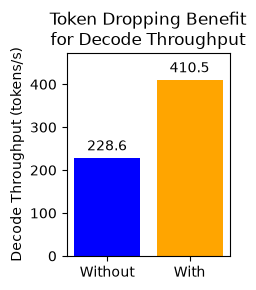

In [9]:
labels = ["Without", "With"]
data = [
    before_drop_data["metrics"]["results"]["output_tput"],
    after_drop_data["metrics"]["results"]["output_tput"],
]

fig, ax = plt.subplots(figsize=(2.5, 3))
bars = ax.bar(labels, data, color=["blue", "orange"])
ax.bar_label(bars, fmt="%.1f", padding=3)
ax.set_ylabel("Decode Throughput (tokens/s)")
ax.set_title("Token Dropping Benefit\nfor Decode Throughput")
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

## Close both contexts

In [10]:
# Only close the context when done.
ctx.close()
qctx.close()